<!-- @@COLAB@@ -->
<a href="https://colab.research.google.com/github/laris-co/ajfon-oracle/blob/main/book/notebooks/ch01_second_brain_20_lines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **เปิดใน Google Colab** — คลิกป้ายด้านบน รันได้ทันทีบนคลาวด์ฟรี ไม่ต้องติดตั้งอะไรในเครื่อง (เซลล์แรกจะ `pip install` ให้เอง)


# 📗 บทที่ 1 — Second Brain แรกของคุณใน 20 บรรทัด

**คู่กับ:** หนังสือบทที่ 1 · สไลด์ Artifact "เห็น Vector Search ด้วยตา"

รันจากบนลงล่าง — จบ notebook นี้คุณจะมี second brain ที่ค้นด้วย **ความหมาย** ได้จริง
และเจอ "ปริศนา" ที่จะพาไปบทที่ 2


## ติดตั้ง (เซลล์เดียว)


In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    %pip -q install chromadb sentence-transformers
import chromadb
print('chromadb', chromadb.__version__, '· พร้อม ✓  (เครื่องเรา: ใช้ kernel vector-book)')


chromadb 1.5.9 · พร้อม ✓  (เครื่องเรา: ใช้ kernel vector-book)


## 1) เปิดสมองที่สอง — ข้อมูลอยู่ในโฟลเดอร์ ไม่มี server


In [2]:
client = chromadb.PersistentClient(path='./chroma_db')
col = client.get_or_create_collection('second_brain_en')
print('collection พร้อม:', col.name)


collection พร้อม: second_brain_en


## 2) ใส่โน้ต (เริ่มด้วยอังกฤษ — เดี๋ยวรู้ว่าทำไม) · upsert = รันซ้ำไม่ duplicate


In [3]:
col.upsert(
    ids=['e1', 'e2', 'e3'],
    documents=[
        'How to teach students vector search: start with cosine similarity',
        'Cold brew recipe: 100g coffee, 1L water, steep 18 hours',
        'Meeting with Professor Fon about the workshop on July 26',
    ],
    metadatas=[{'folder': 'teaching'}, {'folder': 'recipes'}, {'folder': 'meetings'}],
)
print('โน้ตในสมอง:', col.count(), 'ชิ้น')


โน้ตในสมอง: 3 ชิ้น


## 3) ค้นด้วยความหมาย — ไม่มีคำตรงกันก็เจอ

โน้ตเขียนว่า *Meeting* แต่เราค้นว่า *appointment* — คนละคำ ความหมายเดียวกัน


In [4]:
res = col.query(query_texts=['who do I have an appointment with?'], n_results=1)
print('เจอ:', res['documents'][0][0])


เจอ: Meeting with Professor Fon about the workshop on July 26


## ✅ วัดผลตัวเอง #1
รันเซลล์ล่าง — ผ่าน = เข้าใจ upsert/query แล้ว


In [5]:
res = col.query(query_texts=['who do I have an appointment with?'], n_results=1)
assert 'Meeting' in res['documents'][0][0], 'ควรเจอโน้ต Meeting!'
assert col.count() == 3, 'ควรมี 3 ชิ้น (upsert ซ้ำต้องไม่เพิ่ม)'
print('✅ ผ่าน! "appointment" เจอ "Meeting" — ไม่มีคำตรงกันเลยสักตัว')


✅ ผ่าน! "appointment" เจอ "Meeting" — ไม่มีคำตรงกันเลยสักตัว


## 🔍 ปริศนาก่อนจบบท — ทีนี้ลองภาษาไทยบ้าง

ใส่โน้ตไทยชุดเดียวกัน แล้วค้นไทย — **สังเกตผลให้ดี**


In [6]:
col_th = client.get_or_create_collection('second_brain_th')
col_th.upsert(
    ids=['n1', 'n2', 'n3', 'n4', 'n5'],
    documents=[
        'วิธีสอนนักศึกษาให้เข้าใจ vector search: เริ่มจาก cosine similarity ก่อน',
        'สูตรกาแฟ cold brew: กาแฟ 100g น้ำ 1L แช่ 18 ชั่วโมง',
        'ประชุมกับอาจารย์ฝน เรื่อง workshop วันที่ 26 กรกฎาคม ที่มหาวิทยาลัย',
        'Embedding คือการแปลงข้อความเป็นตัวเลขหลายมิติที่เก็บความหมาย',
        'รายการซื้อของ: นม ไข่ ขนมปัง กาแฟดริป',
    ],
    metadatas=[{'folder': 'teaching'}, {'folder': 'recipes'}, {'folder': 'meetings'},
               {'folder': 'teaching'}, {'folder': 'personal'}],
)

for q in ['นัดหมายกับใครบ้าง', 'อยากสอนเรื่อง AI ค้นหา', 'เครื่องดื่ม']:
    res = col_th.query(query_texts=[q], n_results=1)
    print(f'Q: {q}')
    print(f'   คะแนน {1-res["distances"][0][0]:+.3f}  {res["documents"][0][0][:55]}')
    print()
print('❓ อังกฤษเวิร์กสวยงาม แต่ไทยจับคู่เพี้ยน + คะแนนติดลบ — ทำไม?!')
print('→ คำตอบ + วิธีแก้ 30 บรรทัด อยู่ ch02_fix_thai_bge_m3.ipynb')


Q: นัดหมายกับใครบ้าง
   คะแนน -0.130  รายการซื้อของ: นม ไข่ ขนมปัง กาแฟดริป



Q: อยากสอนเรื่อง AI ค้นหา
   คะแนน +0.531  ประชุมกับอาจารย์ฝน เรื่อง workshop วันที่ 26 กรกฎาคม ที



Q: เครื่องดื่ม
   คะแนน -0.130  รายการซื้อของ: นม ไข่ ขนมปัง กาแฟดริป

❓ อังกฤษเวิร์กสวยงาม แต่ไทยจับคู่เพี้ยน + คะแนนติดลบ — ทำไม?!
→ คำตอบ + วิธีแก้ 30 บรรทัด อยู่ ch02_fix_thai_bge_m3.ipynb


## 📊 เห็นภาพ — query ไทยยังอ่อน (ปริศนาของบทนี้)


/var/folders/lf/s98q6y892sl__0brv1tyn0ch0000gn/T/ipykernel_76156/4168274853.py:22: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Thonburi.
  plt.xlabel('cosine  ·  แดง = ต่ำ/ติดลบ = ปัญหา → บทที่ 2 แก้'); plt.tight_layout(); plt.show()
/opt/Code/github.com/laris-co/ajfon-oracle/book/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Thonburi.
  fig.canvas.print_figure(bytes_io, **kw)


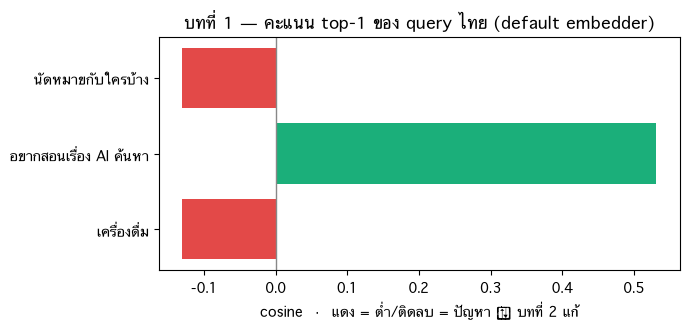

In [7]:
# @@VIZ@@
import matplotlib, matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
_thai_fonts=['Thonburi','Loma','Sarabun','Noto Sans Thai','TH Sarabun New']
_av={f.name for f in _fm.fontManager.ttflist}
if not any(_f in _av for _f in _thai_fonts):
    # Colab/Linux ไม่มีฟอนต์ไทยติดเครื่องมาเลย (DejaVu Sans เรนเดอร์ไทยไม่ได้) — ลงครั้งเดียวแล้ว cache ไว้
    import subprocess
    subprocess.run(['apt-get','-qq','install','-y','fonts-thai-tlwg'], capture_output=True)
    for _p in _fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/tlwg']):
        _fm.fontManager.addfont(_p)
    _av={f.name for f in _fm.fontManager.ttflist}
for _f in _thai_fonts:
    if _f in _av: matplotlib.rcParams['font.family']=_f; break
matplotlib.rcParams['axes.unicode_minus']=False
qs=['นัดหมายกับใครบ้าง','อยากสอนเรื่อง AI ค้นหา','เครื่องดื่ม']
sc=[1-col_th.query(query_texts=[q],n_results=1)['distances'][0][0] for q in qs]
plt.figure(figsize=(7,3.4))
c=['#1baf7a' if s>0.3 else '#e34948' for s in sc]
plt.barh(qs[::-1],sc[::-1],color=c[::-1]); plt.axvline(0,color='#888',lw=1)
plt.title('บทที่ 1 — คะแนน top-1 ของ query ไทย (default embedder)')
plt.xlabel('cosine  ·  แดง = ต่ำ/ติดลบ = ปัญหา → บทที่ 2 แก้'); plt.tight_layout(); plt.show()


## 🏋️ แบบฝึก
1. เพิ่มโน้ตอังกฤษของคุณ 3 ชิ้น แล้วค้นด้วยคำที่**ไม่อยู่ในโน้ต**แต่ความหมายใกล้
2. ลอง query ไทยกับ collection ไทยอีก 2-3 คำ — เพี้ยนแบบเดียวกันไหม? จดไว้เทียบกับบทที่ 2

**บทต่อไป:** `ch02_fix_thai_bge_m3.ipynb` — แก้ปริศนาภาษาไทย


In [8]:
#@title 🔑 เฉลย (คลิกลูกศรซ้ายเพื่อดูวิธีทำ) { display-mode: "form" }

# 1) เพิ่มโน้ตอังกฤษของคุณ 3 ชิ้น แล้วค้นด้วยคำที่ไม่อยู่ในโน้ตเลยแต่ความหมายใกล้
col.upsert(
    ids=['e4', 'e5', 'e6'],
    documents=[
        'My favorite hobby is playing the guitar on weekends',
        'The quarterly budget review is scheduled for next Monday',
        'I need to buy a new laptop charger before the trip',
    ],
    metadatas=[{'folder': 'hobbies'}, {'folder': 'work'}, {'folder': 'shopping'}],
)
res = col.query(query_texts=['music instrument'], n_results=1)
print('ค้น "music instrument" (คำนี้ไม่มีในโน้ตเลยสักตัว) → เจอ:', res['documents'][0][0])

# 2) ลอง query ไทยกับ collection ไทยอีก 2-3 คำ — เพี้ยนแบบเดียวกันไหม?
print()
for q in ['กาแฟใส่นม', 'นัดคุยเรื่องงาน', 'ของกินเล่น']:
    res = col_th.query(query_texts=[q], n_results=1)
    d = res['distances'][0][0]
    print(f'"{q}" → {res["documents"][0][0]}  (distance={d:.3f}{" ⚠️ ห่างเกิน" if d > 0.6 else ""})')
print()
print('สังเกต: query ไทยมักจะ distance สูงกว่า query อังกฤษที่ความหมายใกล้เคียงกัน')
print('→ นี่คือปริศนาภาษาไทยที่ ch02_fix_thai_bge_m3.ipynb จะแก้ให้')


ค้น "music instrument" (คำนี้ไม่มีในโน้ตเลยสักตัว) → เจอ: My favorite hobby is playing the guitar on weekends

"กาแฟใส่นม" → รายการซื้อของ: นม ไข่ ขนมปัง กาแฟดริป  (distance=1.130 ⚠️ ห่างเกิน)
"นัดคุยเรื่องงาน" → รายการซื้อของ: นม ไข่ ขนมปัง กาแฟดริป  (distance=1.130 ⚠️ ห่างเกิน)
"ของกินเล่น" → รายการซื้อของ: นม ไข่ ขนมปัง กาแฟดริป  (distance=1.130 ⚠️ ห่างเกิน)

สังเกต: query ไทยมักจะ distance สูงกว่า query อังกฤษที่ความหมายใกล้เคียงกัน
→ นี่คือปริศนาภาษาไทยที่ ch02_fix_thai_bge_m3.ipynb จะแก้ให้
